In [1]:
import pandas as pd
import numpy as np
import re
import nltk
import seaborn as sns
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /Users/gagu/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [3]:
df = pd.read_csv('spam.csv', encoding='latin-1')

# Keep only required columns
df = df[['v1', 'v2']]
df.columns = ['label', 'message']

print(df.head())

  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


In [4]:
ps = PorterStemmer()
stop_words = set(stopwords.words('english'))

def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)  # remove special chars
    words = text.split()
    words = [ps.stem(w) for w in words if w not in stop_words]
    return " ".join(words)

df['cleaned'] = df['message'].apply(preprocess)

print(df[['message', 'cleaned']].head())

                                             message  \
0  Go until jurong point, crazy.. Available only ...   
1                      Ok lar... Joking wif u oni...   
2  Free entry in 2 a wkly comp to win FA Cup fina...   
3  U dun say so early hor... U c already then say...   
4  Nah I don't think he goes to usf, he lives aro...   

                                             cleaned  
0  go jurong point crazi avail bugi n great world...  
1                              ok lar joke wif u oni  
2  free entri wkli comp win fa cup final tkt st m...  
3                u dun say earli hor u c alreadi say  
4               nah think goe usf live around though  


In [5]:
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

In [6]:
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X = tfidf.fit_transform(df['cleaned']).toarray()

y = df['label']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9775784753363229

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99       965
           1       0.92      0.91      0.92       150

    accuracy                           0.98      1115
   macro avg       0.95      0.95      0.95      1115
weighted avg       0.98      0.98      0.98      1115



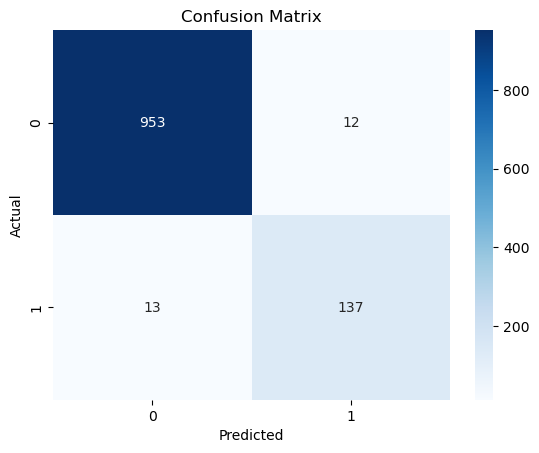

In [9]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [12]:
def predict_spam(text):
    cleaned = preprocess(text)
    vector = tfidf.transform([cleaned]).toarray()
    result = model.predict(vector)[0]
    
    return "SPAM 🚫" if result == 1 else "HAM ✅"


# Continuous user input
while True:
    user_input = input("\nEnter a message (or type 'exit' to quit): ")
    
    if user_input.lower() == 'exit':
        print("Exiting...")
        break
    
    prediction = predict_spam(user_input)
    print("Prediction:", prediction)


Enter a message (or type 'exit' to quit):  hi


Prediction: HAM ✅



Enter a message (or type 'exit' to quit):  Claim your free ringtone now by texting WIN to 80082.


Prediction: SPAM 🚫



Enter a message (or type 'exit' to quit):  exit


Exiting...


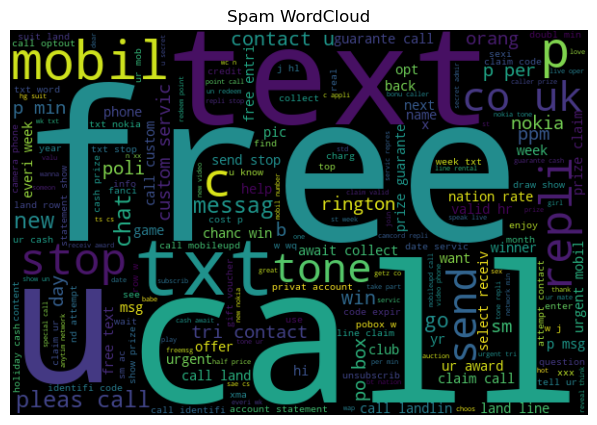

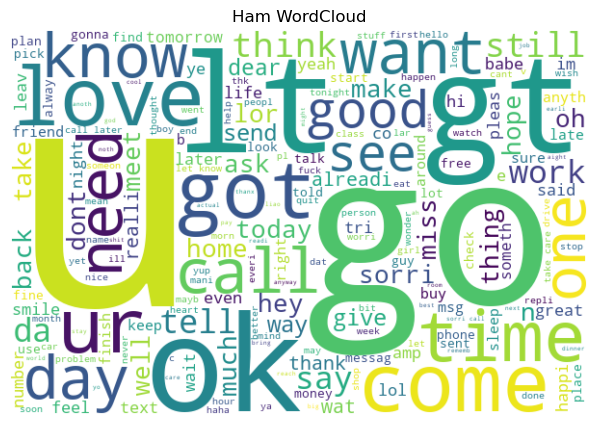

In [13]:
from wordcloud import WordCloud

# Separate spam and ham messages
spam_words = " ".join(df[df['label'] == 1]['cleaned'])
ham_words = " ".join(df[df['label'] == 0]['cleaned'])

# Spam WordCloud
spam_wc = WordCloud(width=600, height=400, background_color='black').generate(spam_words)

plt.figure(figsize=(8,5))
plt.imshow(spam_wc, interpolation='bilinear')
plt.axis('off')
plt.title("Spam WordCloud")
plt.show()

# Ham WordCloud
ham_wc = WordCloud(width=600, height=400, background_color='white').generate(ham_words)

plt.figure(figsize=(8,5))
plt.imshow(ham_wc, interpolation='bilinear')
plt.axis('off')
plt.title("Ham WordCloud")
plt.show()

In [14]:
from collections import Counter

# Spam words
spam_list = spam_words.split()
spam_common = Counter(spam_list).most_common(10)

# Ham words
ham_list = ham_words.split()
ham_common = Counter(ham_list).most_common(10)

print("Top 10 Spam Words:")
for word, count in spam_common:
    print(word, ":", count)

print("\nTop 10 Ham Words:")
for word, count in ham_common:
    print(word, ":", count)

Top 10 Spam Words:
call : 395
free : 228
u : 186
txt : 183
p : 180
text : 146
ur : 144
mobil : 142
stop : 126
claim : 115

Top 10 Ham Words:
u : 1026
go : 422
get : 368
gt : 318
lt : 316
call : 298
come : 297
ok : 287
love : 250
day : 249


In [15]:
import pickle

pickle.dump(model, open('spam_model.pkl', 'wb'))
pickle.dump(tfidf, open('tfidf.pkl', 'wb'))